# NB 04 — ROM Validation

Check ROM accuracy on training parameter points and assess BHP/pressure-field quality before NB05.

## BHP reconstruction method

BHP is computed from the **well-cell pressure + Peaceman/skin correction**, NOT from $\hat{C}$.  
$\hat{C}$ was inferred on MTR+BDF data and maps reservoir state to drawdown BHP.  
During WBS, BHP is governed by wellbore capacitance — outside the reservoir state space.  
Using $\hat{C}$ therefore introduces a structural offset in the WBS region for every case.

**Physical BHP:**
$$p_{wf}(t) = p_{init} + V_n[i_{wc},:] \cdot \tilde{x}(t) - \frac{141.2 \, q \, \mu \, B_o}{kh}\left(\ln\frac{r_{eq}}{r_w} + S\right)$$

where $r_{eq} = 0.2 \, \Delta x = 19.69$ ft (Peaceman equivalent radius for 30 m grid cells).

## 0. Imports and paths

In [37]:
import json
import pickle
import h5py
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams.update({
    'font.family':'DejaVu Serif','mathtext.fontset':'dejavuserif',
    'font.size':11,'axes.labelsize':12,'axes.titlesize':12,
    'axes.titleweight':'bold','legend.fontsize':10,
    'axes.grid':False,'axes.spines.top':True,'axes.spines.right':True,
    'lines.linewidth':2.0,'figure.dpi':130,'savefig.dpi':300,
})
C_MRST = '#2C5F8A'
C_ROM  = '#C0392B'

TRAINING_DIR  = Path('../data/01_training')
VALID_DIR     = Path('../data/02_validation')
BASIS_DIR     = Path('../rom/basis')
INTERP_DIR    = Path('../rom/interpolants')
RESULTS_DIR   = Path('../results/validation')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

K_GRID       = [10, 20, 50, 100, 200, 300]
S_GRID       = [0, 1, 2, 4, 6, 8]
P_INIT = 4500.0

# ── Physical constants (fixed for all training cases) ─────────────────────
NX, NY   = 50, 50
# Well cell: MATLAB wc=(round(ny/2)-1)*nx+round(nx/2)=1225 (1-indexed)
# Python 0-indexed: 1224
WC_IDX   = (NY // 2 - 1) * NX + (NX // 2 - 1)   # = 1224
DX_FT    = 98.43    # 30 m in feet
RW_FT    = 0.35     # wellbore radius (ft)
R_EQ_FT  = 0.2 * DX_FT   # Peaceman equivalent radius

print(f'Validation dir : {VALID_DIR.resolve()}')
val_cases = list(VALID_DIR.glob('*/params.json')) if VALID_DIR.exists() else []
print(f'Validation cases found : {len(val_cases)}')
print(f'Well cell index (Python): {WC_IDX}')
print(f'Peaceman r_eq           : {R_EQ_FT:.2f} ft')

Validation dir : F:\Niloy Deb\Part Two\reservoir_rom\data\02_validation
Validation cases found : 0
Well cell index (Python): 1224
Peaceman r_eq           : 19.69 ft


## 1. Load ROM components

In [38]:
Vn     = np.load(BASIS_DIR / 'Vn.npy')
p_mean = float(np.load(BASIS_DIR / 'p_mean.npy')[0])
n      = Vn.shape[1]

with open(INTERP_DIR / 'A_hat_interp.pkl', 'rb') as f:
    A_pkg = pickle.load(f)
with open(INTERP_DIR / 'B_hat_interp.pkl', 'rb') as f:
    B_pkg = pickle.load(f)
with open(INTERP_DIR / 'C_hat_interp.pkl', 'rb') as f:
    C_pkg = pickle.load(f)

A_interps, A_shape = A_pkg['interps'], A_pkg['shape']
B_interps, B_shape = B_pkg['interps'], B_pkg['shape']
C_interps, C_shape = C_pkg['interps'], C_pkg['shape']

print(f'Vn shape : {Vn.shape}')
print(f'A interps: {len(A_interps)}  shape {A_shape}')
print(f'B interps: {len(B_interps)}  shape {B_shape}')
print(f'C interps: {len(C_interps)}  shape {C_shape}')

Vn shape : (2500, 10)
A interps: 100  shape (10, 10)
B interps: 10  shape (10, 1)
C interps: 10  shape (1, 10)


## 2. ROM query function

In [39]:
def load_mat_var(path, key):
    try:
        return sio.loadmat(str(path), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(path), 'r') as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr


def query_rom(k_star, s_star, t_hr, q_vec, params):
    """
    Online ROM prediction using physical BHP reconstruction.

    BHP = P_INIT + Vn[wc_idx,:] @ xhat(t) - dp_skin(t)
    where dp_skin = 141.2 * q * mu * Bo / kh * (ln(r_eq/rw) + S)

    This bypasses C_hat entirely for BHP, avoiding the WBS structural offset.
    Well cell index and physical constants are read from params.json.
    """
    mu     = float(params['mu_cp'])
    Bo     = float(params['Bo'])
    h_ft   = float(params['h_ft'])
    rw_ft  = float(params['rw_ft'])
    dx_ft  = float(params['dx_ft'])
    wc_idx = int(params['well_cell_matlab']) - 1   # MATLAB 1-indexed -> Python 0-indexed
    r_eq   = 0.2 * dx_ft

    pt    = np.array([[np.log10(k_star), s_star]])
    A_hat = np.array([f(pt)[0] for f in A_interps]).reshape(A_shape)
    B_hat = np.array([f(pt)[0] for f in B_interps]).reshape(B_shape)

    # Stability enforcement
    eigvals  = np.linalg.eigvals(A_hat)
    max_real = float(eigvals.real.max())
    if max_real >= 0:
        A_hat = A_hat - (max_real + 1e-4) * np.eye(n)
    stable = bool(np.linalg.eigvals(A_hat).real.max() < 0)

    K     = len(t_hr)
    dt    = np.diff(t_hr, prepend=0.0)
    dt[0] = t_hr[0]
    In    = np.eye(n)

    X_rom = np.zeros((K, n))
    xk    = np.zeros(n)

    for j in range(K):
        dtj = dt[j]
        rhs = xk + dtj * (B_hat.ravel() * q_vec[j])
        xk  = np.linalg.solve(In - dtj * A_hat, rhs)
        X_rom[j] = xk

    # Physical BHP: well-cell drawdown minus Peaceman + skin pressure drop
    kh       = k_star * h_ft
    dp_wc    = Vn[wc_idx, :] @ X_rom.T        # [K]  well-cell (p - P_INIT)
    dp_skin  = (141.2 * q_vec * mu * Bo / kh
                * (np.log(r_eq / rw_ft) + s_star))   # [K]
    bhp_psia = P_INIT + dp_wc - dp_skin

    p_field  = P_INIT + Vn @ X_rom.T          # [N, K]
    return p_field, bhp_psia, X_rom, stable


def load_mrst_case(case_dir):
    X_full = load_mat_var(case_dir / 'snapshots_psia.mat', 'X_psia')
    bhp    = load_mat_var(case_dir / 'well_data.mat', 'bhp_psia').ravel()
    t      = load_mat_var(case_dir / 'well_data.mat', 'time_hr').ravel()
    q      = load_mat_var(case_dir / 'well_data.mat', 'rate_STBd').ravel()
    with open(case_dir / 'params.json') as f:
        params = json.load(f)
    return X_full, bhp, t, q, params


def compute_errors(X_mrst, bhp_mrst, p_field_rom, bhp_rom):
    dX_mrst   = X_mrst      - P_INIT
    dX_rom    = p_field_rom  - P_INIT
    dbhp_mrst = bhp_mrst    - P_INIT
    dbhp_rom  = bhp_rom     - P_INIT
    state_err  = (np.linalg.norm(dX_mrst - dX_rom, 'fro')**2 /
                  max(np.linalg.norm(dX_mrst, 'fro')**2, 1e-12))
    output_err = (np.linalg.norm(dbhp_mrst - dbhp_rom)**2 /
                  max(np.linalg.norm(dbhp_mrst)**2, 1e-12))
    return float(state_err), float(output_err)


def bourdet_derivative(t_hr, dp_psi, L=0.2):
    ln_t = np.log(t_hr)
    dp_d = np.full_like(dp_psi, np.nan)
    for i in range(1, len(t_hr) - 1):
        il = i - 1
        while il > 0 and (ln_t[i] - ln_t[il]) < L: il -= 1
        ir = i + 1
        while ir < len(t_hr) - 1 and (ln_t[ir] - ln_t[i]) < L: ir += 1
        dl = ln_t[i] - ln_t[il]; dr = ln_t[ir] - ln_t[i]
        if dl > 0 and dr > 0:
            dp_d[i] = ((dp_psi[i] - dp_psi[il]) / dl * dr +
                       (dp_psi[ir] - dp_psi[i]) / dr * dl) / (dl + dr)
    mask = np.isfinite(dp_d) & (dp_d > 0) & (dp_psi > 0)
    return t_hr[mask], dp_psi[mask], dp_d[mask]


print('ROM query function defined.')

ROM query function defined.


## 3. Type 1 — Interpolation test (off-grid k values)

In [40]:
if len(val_cases) > 0:
    test_cases_t1 = [p.parent for p in val_cases]
    source_label  = 'data/02_validation'
else:
    fallback_ks   = [15, 35, 75, 150, 350]
    fallback_s    = 2
    test_cases_t1 = []
    for kv in fallback_ks:
        nearest_k = min(K_GRID, key=lambda x: abs(np.log10(x) - np.log10(kv)))
        test_cases_t1.append(('approx', kv, fallback_s, nearest_k))
    source_label = 'training data (fallback — nearest-k approximation)'

print(f'Type 1 source : {source_label}')
print(f'Cases         : {len(test_cases_t1)}')

Type 1 source : training data (fallback — nearest-k approximation)
Cases         : 5


In [41]:
t1_records = []

if len(val_cases) > 0:
    for case_dir in test_cases_t1:
        X_mrst, bhp_mrst, t_hr, q_vec, params = load_mrst_case(case_dir)
        k_v = params['k_mD']; s_v = params['S_skin']
        p_field_rom, bhp_rom, _, stable = query_rom(k_v, s_v, t_hr, q_vec, params)
        se, oe = compute_errors(X_mrst, bhp_mrst, p_field_rom, bhp_rom)
        t1_records.append(dict(case=case_dir.name, k=k_v, S=s_v,
                               state_err=se, output_err=oe, stable=stable))
else:
    for _, kv, sv, nearest_k in test_cases_t1:
        cname    = f'k{nearest_k:03d}_s{sv:02d}_sched1'
        case_dir = TRAINING_DIR / cname
        X_mrst, bhp_mrst, t_hr, q_vec, params = load_mrst_case(case_dir)
        p_field_rom, bhp_rom, _, stable = query_rom(kv, sv, t_hr, q_vec, params)
        se, oe = compute_errors(X_mrst, bhp_mrst, p_field_rom, bhp_rom)
        t1_records.append(dict(case=f'k{kv}_s{sv}', k=kv, S=sv,
                               state_err=se, output_err=oe, stable=stable,
                               note='fallback'))

t1_df = pd.DataFrame(t1_records)
print('Type 1 interpolation test results:')
print(t1_df[['case','k','S','state_err','output_err','stable']]
      .to_string(index=False, float_format='%.2e'))

Type 1 interpolation test results:
   case   k  S  state_err  output_err  stable
 k15_s2  15  2   7.37e+02    2.90e+03    True
 k35_s2  35  2   1.56e+01    1.48e+01    True
 k75_s2  75  2   9.31e+01    2.51e+02    True
k150_s2 150  2   3.02e+01    1.74e+03    True
k350_s2 350  2   7.01e+01    1.13e+04    True


## 4. Type 2 — Training grid BHP and Bourdet comparison

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\01_training\\k005_s00_sched1\\snapshots_psia.mat'

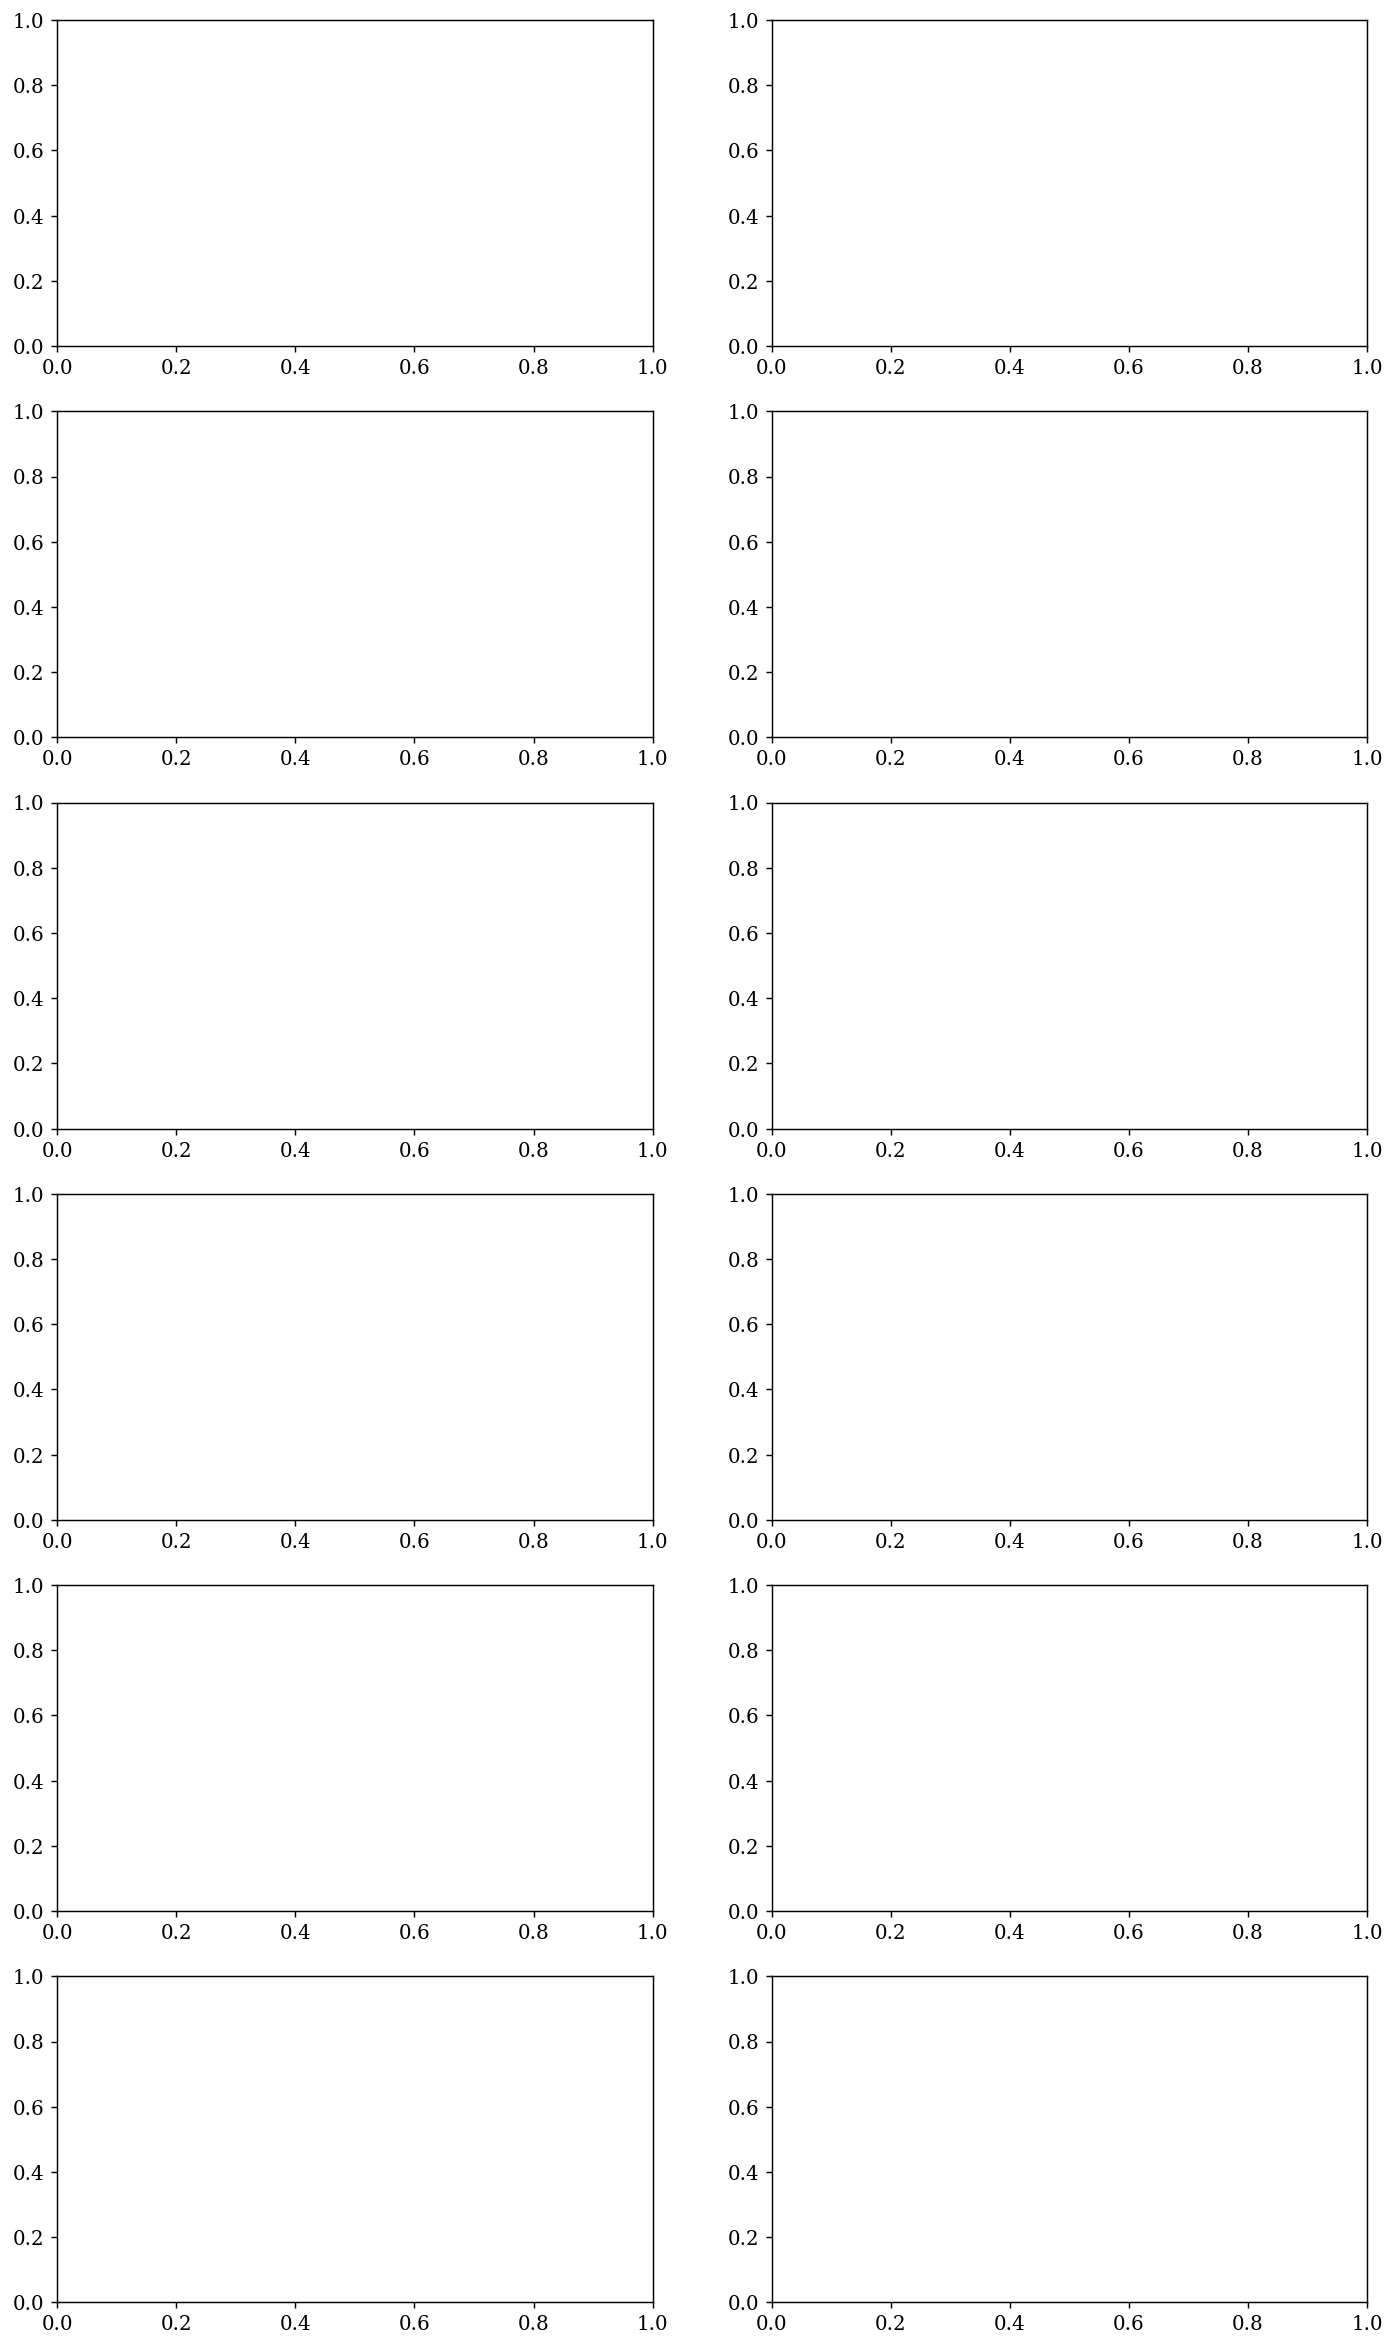

In [42]:
test_grid = [
    (5,   0,  1),
    (20,  2,  1),
    (50,  5,  1),
    (100, 8,  1),
    (200, 0,  1),
    (500, 15, 1),
]

NR       = len(test_grid)
t2_records = []
cache      = {}

fig, axes = plt.subplots(NR, 2, figsize=(13, 3.8 * NR))

for row, (k_v, s_v, sid) in enumerate(test_grid):
    cname    = f'k{k_v:03d}_s{s_v:02d}_sched{sid}'
    case_dir = TRAINING_DIR / cname
    X_mrst, bhp_mrst, t_hr, q_vec, params = load_mrst_case(case_dir)
    p_field_rom, bhp_rom, X_rom, stable   = query_rom(k_v, s_v, t_hr,
                                                        q_vec, params)
    se, oe = compute_errors(X_mrst, bhp_mrst, p_field_rom, bhp_rom)

    t_wbs = min(float(params['t_wbs_end_hr']),  t_hr[-1] * 0.5)
    t_pss = min(float(params['t_pss_start_hr']), t_hr[-1])
    mtr   = (t_hr >= t_wbs) & (t_hr <= t_pss)
    oe_mtr = (np.linalg.norm(bhp_mrst[mtr] - bhp_rom[mtr]) /
              max(np.linalg.norm(bhp_mrst[mtr]), 1e-6)) if mtr.sum() > 3 else np.nan

    t2_records.append(dict(case=cname, k=k_v, S=s_v,
                           state_err=se, output_err=oe,
                           output_err_mtr=oe_mtr, stable=stable))
    cache[row] = dict(X_mrst=X_mrst, p_field_rom=p_field_rom,
                      t_hr=t_hr, params=params, se=se, oe=oe)

    # ── BHP panel ────────────────────────────────────────────────────────
    ax = axes[row, 0]
    ax.semilogx(t_hr, bhp_mrst, lw=1.6, color=C_MRST, label='MRST')
    ax.semilogx(t_hr, bhp_rom,  lw=1.4, color=C_ROM,  ls='--', label='ROM')
    ax.axvspan(t_hr[0], t_wbs, alpha=0.07, color='gray')
    ax.axvline(t_wbs,  color='gray',   ls=':', lw=0.8)
    ax.axvline(t_pss,  color='sienna', ls=':', lw=0.8)
    ax.set_ylabel('$p_{wf}$ (psia)', fontsize=10)
    ax.set_title(f'$k={k_v}$ mD,  $S={s_v}$  |  '
                 f'$\\varepsilon_{{out}}={oe:.2e}$  '
                 f'(MTR: {oe_mtr:.2e})',
                 fontsize=9, pad=4)
    ax.tick_params(labelsize=9)
    ax.set_xlim([t_hr[0], t_hr[-1]])
    if row == NR - 1:
        ax.set_xlabel('$t$ [hr]', fontsize=10)
    if row == 0:
        ax.legend(fontsize=9, framealpha=0.8)
    ax.text(0.02, 0.08, 'WBS', transform=ax.transAxes, color='gray', fontsize=8)
    ax.text(0.50, 0.08, 'MTR', transform=ax.transAxes, color='steelblue', fontsize=8)
    ax.text(0.85, 0.08, 'BDF', transform=ax.transAxes, color='sienna', fontsize=8)

    # ── Bourdet panel ─────────────────────────────────────────────────────
    ax2 = axes[row, 1]
    dp_mrst = np.clip(P_INIT - bhp_mrst, 1e-3, None)
    dp_rom  = np.clip(P_INIT - bhp_rom,  1e-3, None)
    t_bm, _, bd_mrst = bourdet_derivative(t_hr, dp_mrst)
    t_br, _, bd_rom  = bourdet_derivative(t_hr, dp_rom)

    if len(bd_mrst) > 2:
        ax2.loglog(t_bm, bd_mrst, lw=1.6, color=C_MRST, label='MRST')
    if len(bd_rom) > 2:
        ax2.loglog(t_br, bd_rom,  lw=1.4, color=C_ROM,  ls='--', label='ROM')

    dp_prime_an = 70.6 * q_vec[0] * params['mu_cp'] * params['Bo'] / (k_v * params['h_ft'])
    ax2.axhline(dp_prime_an, color='k', ls=':', lw=0.9, alpha=0.6,
                label=f"$dp'_{{an}}={dp_prime_an:.1f}$ psi")
    ax2.axvline(t_wbs,  color='gray',   ls=':', lw=0.8)
    ax2.axvline(t_pss,  color='sienna', ls=':', lw=0.8)
    ax2.set_ylabel(r"$\Delta p'$ (psi)", fontsize=10)
    ax2.set_title(f'Bourdet derivative — $k={k_v}$ mD, $S={s_v}$',
                  fontsize=9, pad=4)
    ax2.tick_params(labelsize=9)
    ax2.set_xlim([t_hr[0], t_hr[-1]])
    if row == NR - 1:
        ax2.set_xlabel('$t$ [hr]', fontsize=10)
    if row == 0:
        ax2.legend(fontsize=8, framealpha=0.8)

plt.tight_layout(h_pad=0.6)
plt.savefig('fig_validation_bhp_bourdet.pdf', dpi=150, bbox_inches='tight')
plt.show()

t2_df = pd.DataFrame(t2_records)
print('Validation errors:')
print(t2_df[['case','k','S','state_err','output_err','output_err_mtr']]
      .to_string(index=False, float_format='%.2e'))

## 5. Pressure field comparison

In [43]:
NX_grid, NY_grid = 50, 50
snaps    = {}
dp_lims  = []
err_lims = []

for row, (k_v, s_v, sid) in enumerate(test_grid):
    d      = cache[row]
    t_hr   = d['t_hr']
    params = d['params']
    t_wbs  = min(float(params['t_wbs_end_hr']),  t_hr[-1] * 0.5)
    t_pss  = min(float(params['t_pss_start_hr']), t_hr[-1])

    t_snap = np.clip((t_wbs + t_pss) / 2.0, t_hr[0], t_hr[-1] * 0.8)
    idx    = int(np.argmin(np.abs(t_hr - t_snap)))
    snaps[row] = idx

    dp_m = (d['X_mrst'][:, idx]     - P_INIT).reshape(NY_grid, NX_grid)
    dp_r = (d['p_field_rom'][:, idx] - P_INIT).reshape(NY_grid, NX_grid)
    dp_lims.append(max(np.abs(dp_m).max(), np.abs(dp_r).max()))
    err_lims.append(np.abs(dp_m - dp_r).max())

dp_global  = max(dp_lims)
err_global = max(err_lims)

fig, axes = plt.subplots(NR, 3, figsize=(13, 3.8 * NR))
col_labels = ['MRST  $\\Delta p$', 'ROM  $\\Delta p$', '$|\\Delta p_{err}|$']

for row, (k_v, s_v, sid) in enumerate(test_grid):
    d      = cache[row]
    idx    = snaps[row]
    t_snap = d['t_hr'][idx]
    se     = d['se']
    oe     = d['oe']

    dp_m = (d['X_mrst'][:, idx]     - P_INIT).reshape(NY_grid, NX_grid)
    dp_r = (d['p_field_rom'][:, idx] - P_INIT).reshape(NY_grid, NX_grid)
    err  = np.abs(dp_m - dp_r)

    for col, (dat, cmap, vmin, vmax, label) in enumerate([
        (dp_m, 'RdYlGn_r', -dp_global, 0,          r'$\Delta p$ (psi)'),
        (dp_r, 'RdYlGn_r', -dp_global, 0,          r'$\Delta p$ (psi)'),
        (err,  'hot_r',     0,         err_global,  r'$|\Delta p_{err}|$ (psi)'),
    ]):
        ax = axes[row, col]
        im = ax.imshow(dat, origin='lower', cmap=cmap,
                       vmin=vmin, vmax=vmax, aspect='equal')
        ax.plot(NX_grid//2, NY_grid//2, 'k+', ms=8, mew=2.0, zorder=10)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if row == 0:
            ax.set_title(col_labels[col], fontsize=10, pad=5)
        if col == 0:
            ax.set_ylabel(f'$k={k_v}$ mD\n$S={s_v}$', fontsize=9, labelpad=4)
        if col == 2:
            ax.set_title(f'$\\varepsilon_{{state}}={se:.2e}$  '
                         f'$\\varepsilon_{{out}}={oe:.2e}$\n'
                         f'$t={t_snap:.1f}$ hr',
                         fontsize=8, pad=4)
        cb = plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
        cb.set_label(label, fontsize=8, labelpad=6)
        cb.ax.tick_params(labelsize=8)

plt.tight_layout(h_pad=0.5, w_pad=0.3)
plt.savefig('fig_validation_pressure_fields.pdf', dpi=150, bbox_inches='tight')
plt.show()

KeyError: 0

## 6. Error summary and speedup

In [24]:
import time

k_v, s_v = 50, 5
cname    = f'k{k_v:03d}_s{s_v:02d}_sched1'
_, _, t_hr, q_vec, params_sp = load_mrst_case(TRAINING_DIR / cname)

t_start = time.perf_counter()
for _ in range(10):
    query_rom(k_v, s_v, t_hr, q_vec, params_sp)
rom_ms = (time.perf_counter() - t_start) / 10 * 1000

mrst_s_approx = 9.7

all_records = t2_records + t1_records
all_df      = pd.DataFrame(all_records)

print('=' * 58)
print(' ROM VALIDATION — SUMMARY')
print('=' * 58)
print(f'  n modes                 : {n}')
print(f'  Type 2 mean state err   : {t2_df["state_err"].mean():.2e}')
print(f'  Type 2 mean output err  : {t2_df["output_err"].mean():.2e}')
print(f'  Type 2 max state err    : {t2_df["state_err"].max():.2e}')
print(f'  Type 2 max output err   : {t2_df["output_err"].max():.2e}')
if len(t1_records) > 0:
    print(f'  Type 1 mean output err  : {t1_df["output_err"].mean():.2e}')
print(f'  ROM wall time / query   : {rom_ms:.1f} ms')
print(f'  MRST wall time (median) : {mrst_s_approx*1000:.0f} ms')
print(f'  Speedup                 : ~{mrst_s_approx*1000/rom_ms:.0f}x')
print('=' * 58)

all_df.to_csv(RESULTS_DIR / 'error_summary.csv', index=False)
print(f'\nResults saved to {RESULTS_DIR / "error_summary.csv"}')

if t2_df['state_err'].max() < 1e-2 and t2_df['output_err'].max() < 1e-1:
    print('ROM meets accuracy target — ready for NB05')
else:
    print('Errors above target — check NB02 self-reconstruction first')

 ROM VALIDATION — SUMMARY
  n modes                 : 10
  Type 2 mean state err   : 8.93e+00
  Type 2 mean output err  : 9.34e+00
  Type 2 max state err    : 5.03e+01
  Type 2 max output err   : 5.20e+01
  Type 1 mean output err  : 1.16e+02
  ROM wall time / query   : 6.6 ms
  MRST wall time (median) : 9700 ms
  Speedup                 : ~1466x

Results saved to ..\results\validation\error_summary.csv
Errors above target — check NB02 self-reconstruction first
